## Visium Fluorescence Image Analysis with Squidpy

This notebook explores a pre-processed **10x Genomics Visium** mouse brain coronal section using **Squidpy**, combining spatial transcriptomics data with a 3-channel fluorescence microscopy image.

The tissue image contains three biologically important markers:

* **Channel 0 – DAPI:** stains DNA and highlights cell nuclei
* **Channel 1 – anti-NEUN:** labels neuronal cells
* **Channel 2 – anti-GFAP:** labels glial cells, especially astrocytes

Unlike standard gene-expression-only analysis, this notebook focuses on extracting **image-derived features** from each Visium spot and comparing them with previously computed transcriptomic cluster labels.

Since preprocessing steps such as quality control, normalization, dimensionality reduction, and clustering were completed earlier, we directly load the processed results and perform image-based downstream analysis.

### Objectives

By the end of this notebook, we will:

1. **Load** the pre-processed `AnnData` object and fluorescence `ImageContainer`
2. **Visualize** spatial gene-expression clusters across the tissue section
3. **Apply smoothing and segmentation** to identify nuclei and tissue structures
4. **Compute image features** (intensity, morphology, segmentation statistics) for each Visium spot
5. **Compare imaging patterns** with gene-expression clusters to uncover spatial biological relationships

This workflow demonstrates how microscopy images can complement transcriptomic data, helping reveal tissue organization, cell-type distributions, and morphology-associated molecular patterns.


In [1]:
!pip install scanpy squidpy igraph leidenalg scikit-image dask

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 25.3 MB/s eta 0:00:00
   ━━━

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

img   = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

INFO     Downloading visium_fluo_image_crop.tiff from                                                              
         https://exampledata.scverse.org/squidpy/figshare/visium_fluo_image_crop.tiff                              


  0%|                                               | 0.00/317M [00:00<?, ?B/s]

INFO     Downloading visium_fluo_adata_crop.h5ad from                                                              
         https://exampledata.scverse.org/squidpy/figshare/visium_fluo_adata_crop.h5ad                              


  0%|                                              | 0.00/68.7M [00:00<?, ?B/s]

### Imports and Data Loading

We load two objects. `adata` is an AnnData object containing the gene
expression counts and pre-computed cluster labels. `img` is a Squidpy
`ImageContainer` holding the high-resolution fluorescence tissue image.

The dataset is a cropped region of the full brain section — this keeps
computation fast while demonstrating the full pipeline.

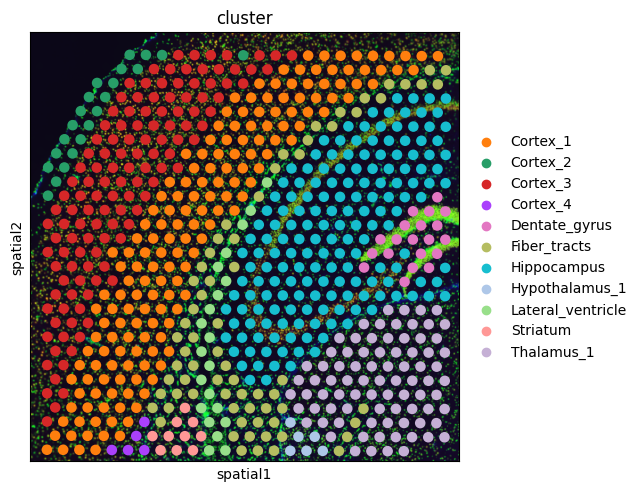

In [3]:
sq.pl.spatial_scatter(adata, color="cluster")

### Spatial Cluster Overview

Before doing any image analysis, we first visualize the pre-annotated
cluster labels in spatial coordinates. This gives us a reference to
compare against once we extract image features — the goal is to see
whether the image captures similar structure to the gene expression.

In [4]:
sq.im.process(img=img, layer="image", method="smooth")

### Image Smoothing

Before segmenting cells, we smooth the image using a Gaussian filter.
This reduces noise and small intensity fluctuations that would otherwise
cause the segmentation algorithm to produce fragmented, inaccurate results.
The smoothed image is stored as a new layer called "image_smooth" inside
the ImageContainer.

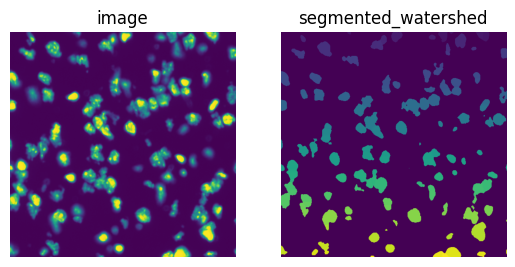

In [5]:
sq.im.segment(img=img, layer="image_smooth", method="watershed", channel=0, chunks=1000)

fig, ax = plt.subplots(1, 2)
img_crop = img.crop_corner(2000, 2000, size=500)
img_crop.show(layer="image", channel=0, ax=ax[0])
img_crop.show(layer="segmented_watershed", channel=0, ax=ax[1])

### Nucleus Segmentation

We segment the DAPI channel (channel 0) using the watershed algorithm.
Watershed treats the image like a topographic map and finds boundaries
between bright nuclei regions. The result is a label image where each
segmented nucleus has a unique integer ID.

We crop a small region to visually compare the raw DAPI channel (left)
against the segmentation mask (right) and check quality.

In [6]:
features_kwargs = {"segmentation": {"label_layer": "segmented_watershed"}}
sq.im.calculate_image_features(
    adata, img,
    features="segmentation",
    layer="image",
    key_added="features_segmentation",
    n_jobs=1,
    features_kwargs=features_kwargs,
)

  0%|          | 0/704 [00:00<?, ?/s]

### Calculating Segmentation Features

For each Visium spot, we calculate features derived from the segmentation:
how many nuclei are under that spot, their average size, and the mean
fluorescence intensity per channel. This produces a new obs × features
matrix stored in `adata.obsm["features_segmentation"]`.

These features describe the cellular content and morphology at each spot,
which is complementary to the gene expression data.

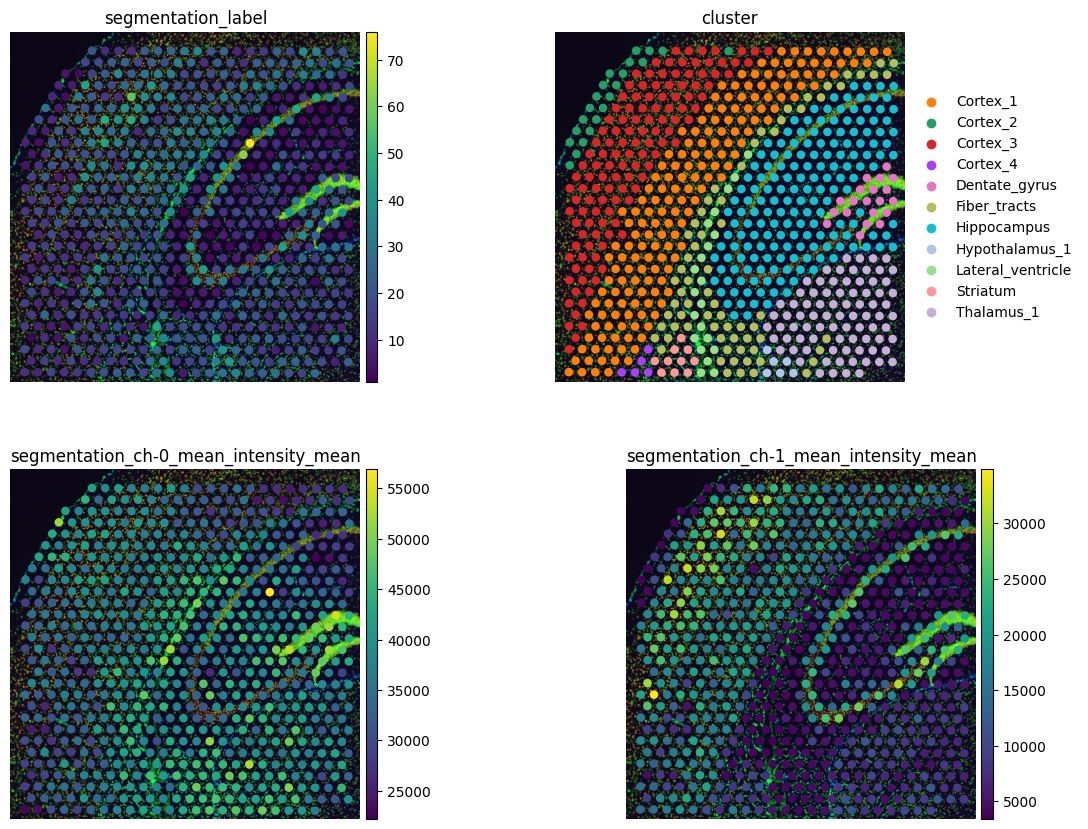

In [7]:
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "features_segmentation"),
    color=[
        "segmentation_label",
        "cluster",
        "segmentation_ch-0_mean_intensity_mean",
        "segmentation_ch-1_mean_intensity_mean",
    ],
    frameon=False,
    ncols=2,
)

### Comparing Image Features to Gene Expression Clusters

`sq.pl.extract` pulls the image features into `adata.obs` so they can
be passed to the plotting function. We plot four panels side by side:
nucleus count per spot, cluster label, mean DAPI intensity, and mean
NEUN intensity.

If the image features and gene-expression clusters agree spatially,
it confirms that both modalities are capturing the same underlying
tissue biology.